In [ ]:
import healpy as hp
import numpy as np
from astropy.io import ascii
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

from funbin import funbin
from funbin.geometry import Box, Point, Polygon, as_poly_collection, tile_negative_space
from funbin.maps import read_shapefile

In [2]:
# PROJ = None
PROJ = "mollweide"

In [3]:
box = Box(Point(-np.pi, -np.pi / 2), 2 * np.pi, np.pi)

# Making tiling (countries + healpix for ocean)

In [4]:
def get_healpixels(nside: int) -> list[Polygon]:
    result: list[Polygon] = []
    npix = hp.nside2npix(nside)

    for pix in range(npix):
        vectors = hp.boundaries(nside, pix, step=3)

        vectors = vectors.T.reshape(-1, 3)
        dnorm = np.sqrt(np.sum(np.square(vectors), axis=1))
        theta = np.arccos(vectors[:, 2] / dnorm)
        phi = np.arctan2(vectors[:, 1], vectors[:, 0])
        # phi[phi < 0] += 2 * np.pi

        lat = np.pi / 2 - theta
        # lon = np.unwrap(phi) if (np.abs(lat) < np.pi / 2 - 1e-6).all() else phi
        lon = np.unwrap(phi, period=1.99999999 * np.pi)  # HACK

        for lon_offset in (-2 * np.pi, 0, 2 * np.pi):
            poly = Polygon(np.stack((lon + lon_offset, lat)).T)
            if poly.bbox.right < -np.pi or poly.bbox.left > np.pi:
                continue
            result.append(poly)

    return result

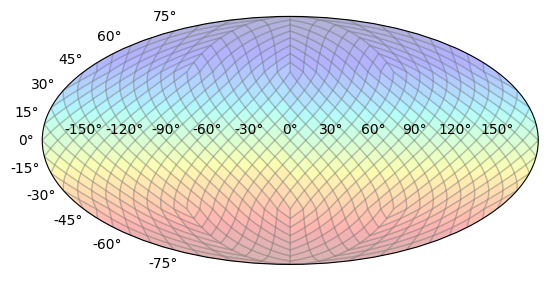

In [5]:
fig = plt.figure()
ax = fig.add_subplot(111, projection=PROJ)

healpixels = get_healpixels(nside=8)
ax.add_collection(as_poly_collection(healpixels[:], coloring="sequential", alpha=0.3))
if PROJ is None:
    # extent = 2
    # box = Box(Point(-extent/2 * np.pi, -np.pi / 2), extent * np.pi, np.pi)
    box.fit_axes(ax)

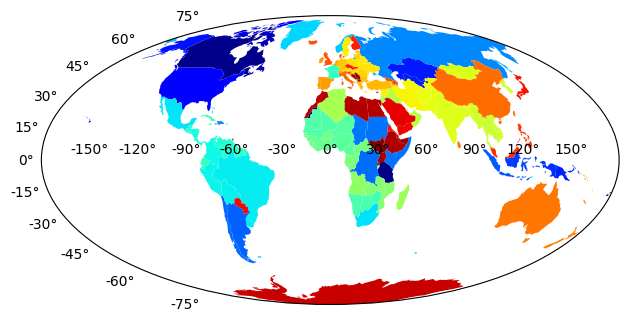

In [6]:
fig = plt.figure()
ax = fig.add_subplot(projection=PROJ)

countries_deg = read_shapefile("ne_110m_admin_0_countries.zip")
# ax.add_collection(as_poly_collection(countries, coloring="sequential", edgecolors="none"))
# Box.bounding_all(countries).fit_axes(ax)
countries = [p.to_radians() for p in countries_deg if p.area > 0.1]
countries = [p for p in countries]

ax.add_collection(as_poly_collection(countries, coloring="sequential", edgecolors="none"))
if PROJ is None:
    box.fit_axes(ax)
fig.tight_layout()

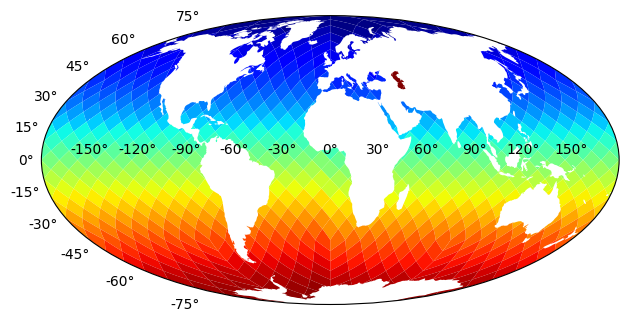

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection=PROJ)

ocean = tile_negative_space(polys=countries, tiling=healpixels, box=box)

ax.add_collection(as_poly_collection(ocean, coloring="sequential", edgecolors="none"))
if PROJ is None:
    box.fit_axes(ax)
fig.tight_layout()

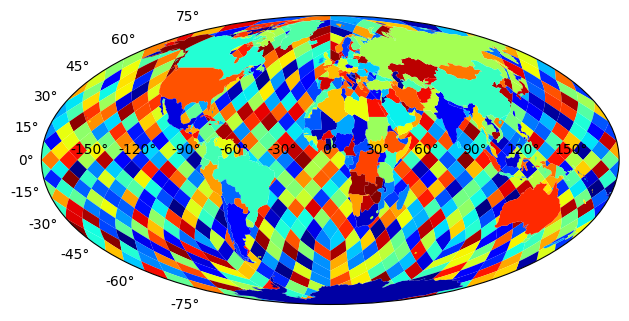

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection=PROJ)

ax.add_collection(as_poly_collection(ocean + countries, coloring="sequential", edgecolors="none"))
if PROJ is None:
    box.fit_axes(ax)
fig.tight_layout()

# Data

In [ ]:
path = "misc/J-Biteau-2021/table5.mrt"

key_import = ["Name", "GLON", "GLAT", "distL", "Mstar", "SFR", "cNm", "cNs"]
table = ascii.read(path, include_names=key_import)

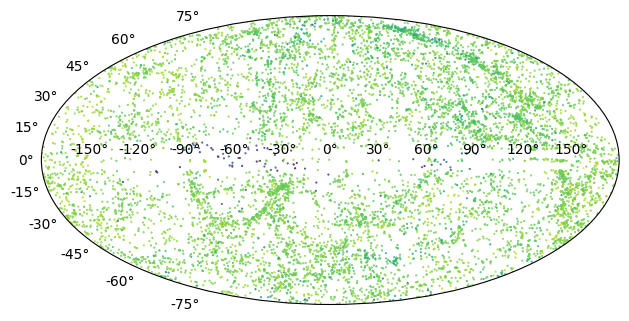

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection=PROJ)

mask = table["distL"] < 200
t = table[mask]
weights = np.power(10, t["Mstar"]) / (t["cNm"])
# ax.hist2d(x=t["GLON"], y=t["GLAT"], bins=200, weights=weights)
length = 10000
ax.scatter(
    t["GLON"][:length] * (np.pi / 180) - np.pi,
    t["GLAT"][:length] * (np.pi / 180),
    marker=".",
    c=weights[:length],
    s=1,
    norm="log",
)

fig.tight_layout()

In [11]:
mask = (table["cNm"] > 1e-8) & (table["distL"] < 200)
glon = np.array(table[mask]["GLON"])
glat = np.array(table[mask]["GLAT"])
weights = np.array(np.power(10, table[mask]["Mstar"]) / table[mask]["cNm"])
print(f"Selected {glon.size} events")

Selected 141093 events


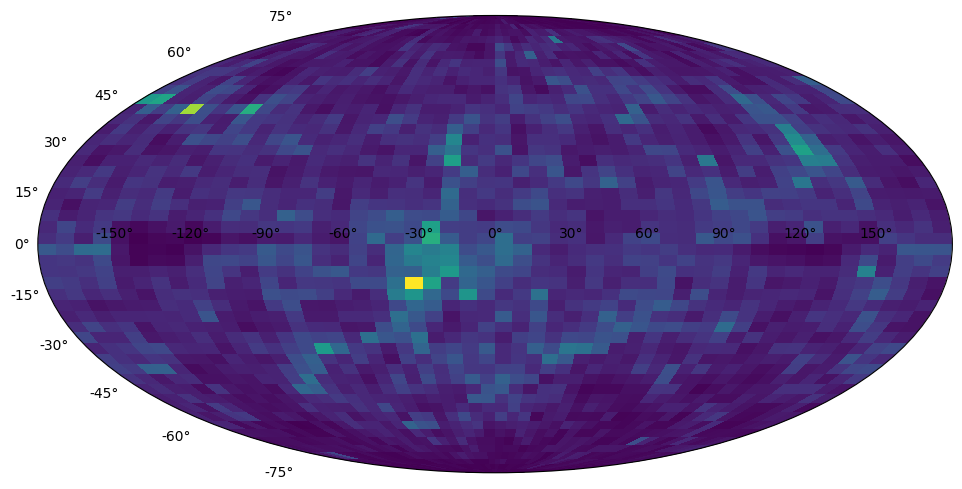

In [12]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(projection=PROJ)

subsample = 1000000
h, xedges, yedges = np.histogram2d(
    x=np.radians(glon[:subsample]) - np.pi,
    y=np.radians(glat[:subsample]),
    bins=50,
    # density=True,
    # weights=weights,
)

pc = ax.pcolormesh(xedges, yedges, h.T, norm="linear")
fig.tight_layout()

Clipping colors to [13.201633590433, 15.590132135749254]


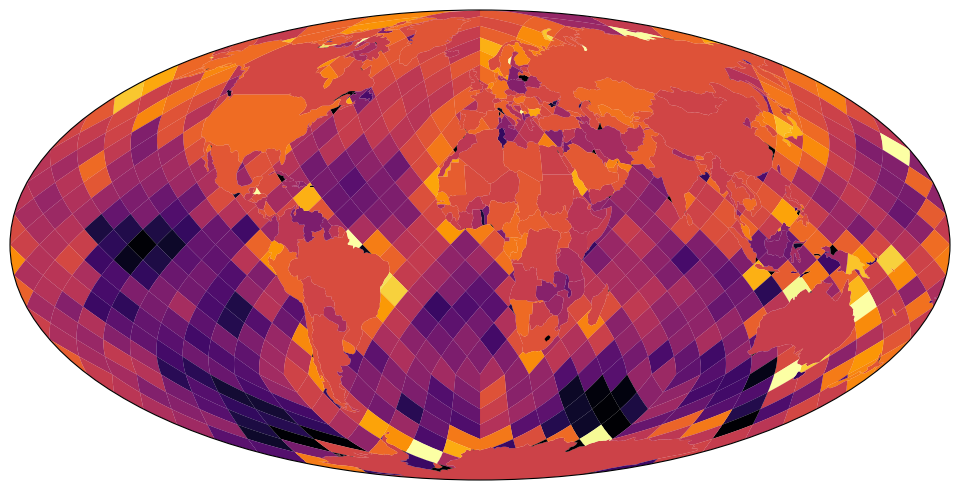

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(projection=PROJ)


def adaptive_lognorm(pixel_values: list[float]) -> LogNorm:
    pv = np.array(pixel_values)
    pv = pv[pv > 0]
    vmin = np.quantile(pv, q=0.03)
    vmax = np.quantile(pv, q=0.99)
    print(f"Clipping colors to [{np.log10(vmin)}, {np.log10(vmax)}]")
    return LogNorm(vmin, vmax, clip=True)  # type: ignore


subsample = 1000000
pc = funbin(
    ax=ax,
    x=np.radians(glon[:subsample]) - np.pi,
    y=np.radians(glat[:subsample]),
    weights=weights[:subsample],
    tiling=countries + ocean,
    density=True,
    norm=adaptive_lognorm,
    cmap="inferno",
    is_spherical=True,
    # edgecolor="gray",
)
ax.grid(False)
ax.set_xticks([])
ax.set_yticks([])
# fig.colorbar(pc, ax=ax, orientation="horizontal", fraction=0.05, aspect=60)
fig.tight_layout()
fig.savefig("media/paper/-world-test.pdf")
fig.savefig("media/paper/-world-test.png", dpi=300)